In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_submission_df = pd.read_csv('sample_submission.csv')


In [ ]:
train_df['date'] = pd.to_datetime(train_df['date'], errors='coerce')
test_df['date'] = pd.to_datetime(test_df['date'], errors='coerce')


In [ ]:
# Check for any rows where the conversion failed
print(train_df[train_df['date'].isna()])
print(test_df[test_df['date'].isna()])


In [ ]:
train_df = train_df.dropna(subset=['date'])
test_df = test_df.dropna(subset=['date'])


In [ ]:
print(train_df.info())
print(train_df.head())
print(test_df.info())
print(test_df.head())


In [ ]:
# Summary statistics
print(train_df.describe())

# Check for missing values
print(train_df.isnull().sum())

In [ ]:
# Summary statistics
print(test_df.describe())

# Check for missing values
print(test_df.isnull().sum())

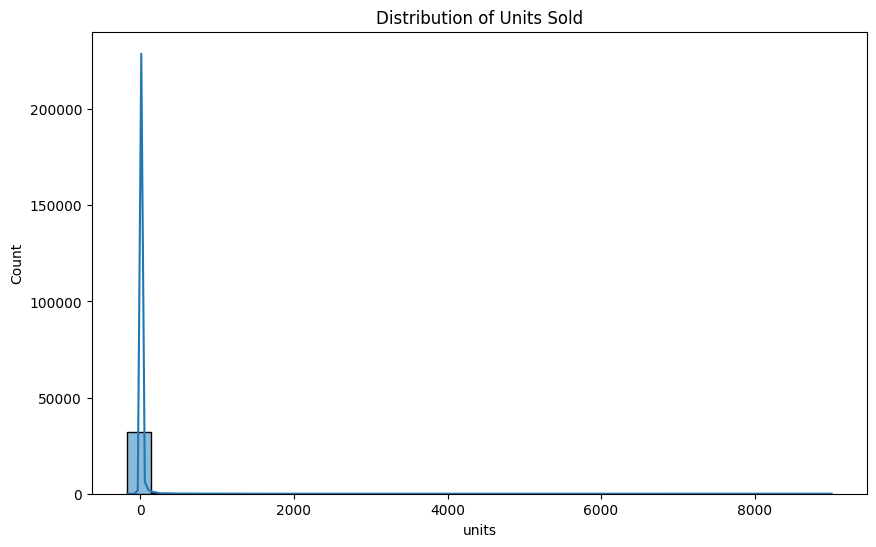

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(train_df['units'], bins=30, kde=True)
plt.title('Distribution of Units Sold')
plt.show()

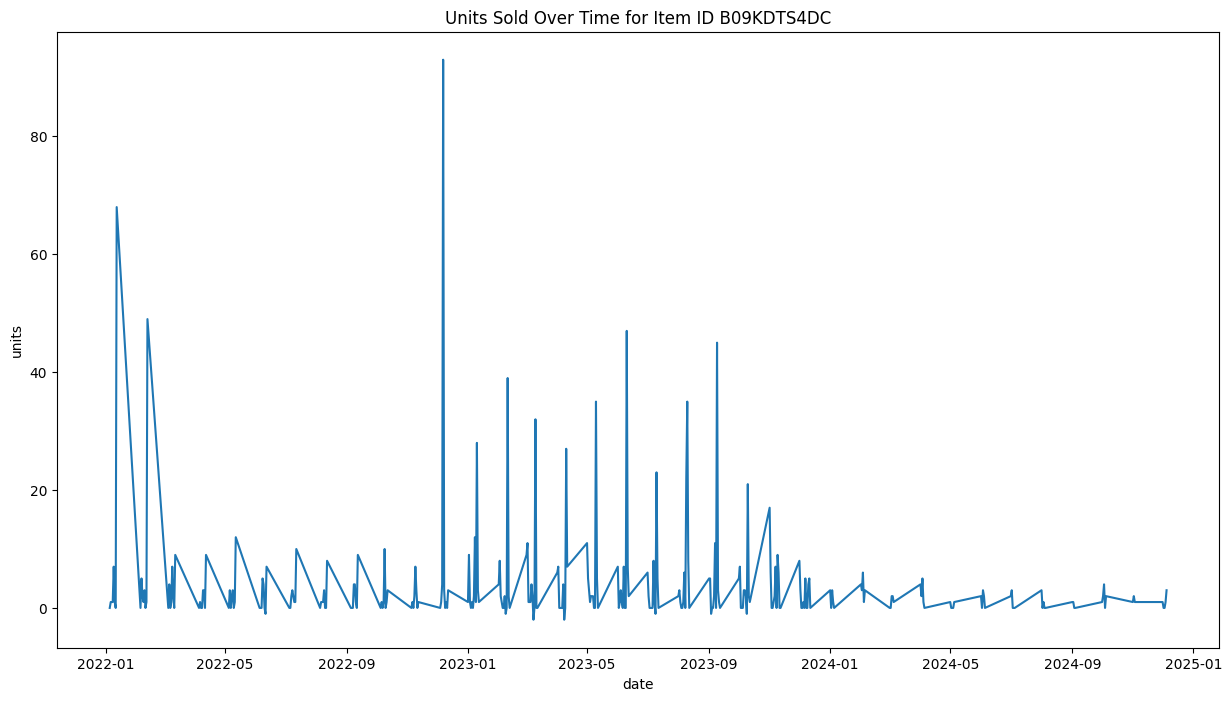

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
# Time series plot of units sold over time for a sample item
sample_item_id = train_df['Item Id'].unique()[0]
sample_item_data = train_df[train_df['Item Id'] == sample_item_id]

plt.figure(figsize=(15, 8))
sns.lineplot(data=sample_item_data, x='date', y='units')
plt.title(f'Units Sold Over Time for Item ID {sample_item_id}')
plt.show()

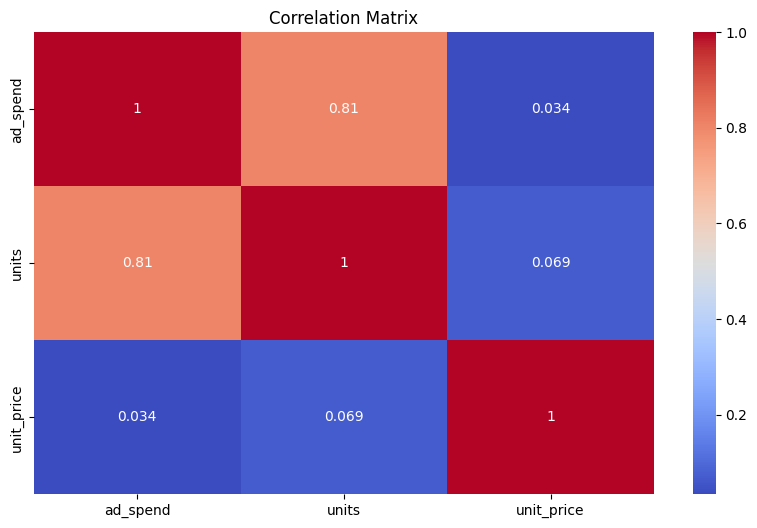

In [38]:
# Correlation matrix
numeric_df = train_df.select_dtypes(include=['number'])

# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [39]:
# Generate date-related features
train_df['year'] = train_df['date'].dt.year
train_df['month'] = train_df['date'].dt.month
train_df['day'] = train_df['date'].dt.day
train_df['dayofweek'] = train_df['date'].dt.dayofweek

test_df['year'] = test_df['date'].dt.year
test_df['month'] = test_df['date'].dt.month
test_df['day'] = test_df['date'].dt.day
test_df['dayofweek'] = test_df['date'].dt.dayofweek


In [40]:
# Handle missing values
# 1. Remove rows with missing 'Item Id'
train_df = train_df.dropna(subset=['Item Id'])

# 2. Replace missing 'Item Name' with 'Unknown'
train_df['Item Name'] = train_df['Item Name'].fillna('Unknown')

# 3. Impute missing 'ad_spend', 'orderedrevenueamount', 'unit_price' with median
if 'ad_spend' in train_df.columns:
    train_df['ad_spend'] = train_df['ad_spend'].fillna(train_df['ad_spend'].median())

if 'orderedrevenueamount' in train_df.columns:
    train_df['orderedrevenueamount'] = train_df['orderedrevenueamount'].fillna(train_df['orderedrevenueamount'].median())

if 'unit_price' in train_df.columns:
    train_df['unit_price'] = train_df['unit_price'].fillna(train_df['unit_price'].median())

# 4. Handle missing 'units'
# If dropping rows with missing 'units' is acceptable
train_df = train_df.dropna(subset=['units'])

# Check if all missing values are handled
print("Missing values in the dataset after handling:\n", train_df.isnull().sum())

# Save the cleaned data (optional)
train_df.to_csv('cleaned_train.csv', index=False)


Missing values in the dataset after handling:
 ID            0
date          0
Item Id       0
Item Name     0
ad_spend      0
anarix_id     0
units         0
unit_price    0
year          0
month         0
day           0
dayofweek     0
dtype: int64


In [41]:
# Check column names to ensure proper handling
print("Column names in test_df:", test_df.columns)

# Handle missing values
# 1. Replace missing 'Item Name' with 'Unknown'
test_df['Item Name'] = test_df['Item Name'].fillna('Unknown')

# 2. Impute missing 'ad_spend' with median
if 'ad_spend' in test_df.columns:
    test_df['ad_spend'] = test_df['ad_spend'].fillna(test_df['ad_spend'].median())

# Check if all missing values are handled
print("Missing values in the dataset after handling:\n", test_df.isnull().sum())

# Save the cleaned data (optional)
test_df.to_csv('cleaned_test.csv', index=False)

Column names in test_df: Index(['ID', 'date', 'Item Id', 'Item Name', 'ad_spend', 'anarix_id',
       'unit_price', 'year', 'month', 'day', 'dayofweek'],
      dtype='object')
Missing values in the dataset after handling:
 ID            0
date          0
Item Id       0
Item Name     0
ad_spend      0
anarix_id     0
unit_price    0
year          0
month         0
day           0
dayofweek     0
dtype: int64


In [42]:
# Check for existing columns in train_df
print("Columns in train_df:", train_df.columns)


Columns in train_df: Index(['ID', 'date', 'Item Id', 'Item Name', 'ad_spend', 'anarix_id', 'units',
       'unit_price', 'year', 'month', 'day', 'dayofweek'],
      dtype='object')


In [46]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Feature extraction
X_train = train_df[['ad_spend', 'unit_price']]
y_train = train_df['units']
X_test = test_df[['ad_spend', 'unit_price']]

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the model
model = RandomForestRegressor(random_state=42)
model.fit(X_train_scaled, y_train)

# Predicting the units for the test data
test_predictions = model.predict(X_test_scaled)

# Adding the predictions to the test dataframe
test_df['predicted_units'] = test_predictions

print("Predictions added to test data:")
print(test_df[['ID', 'Item Id', 'predicted_units']])


Predictions added to test data:
                         ID  Item Id  predicted_units
0     2024-07-01_B09KDR64LT        5         8.104667
1     2024-07-01_B09KDTS4DC        8         8.104667
2     2024-07-01_B09KDTHJ6V        7         8.104667
3     2024-07-01_B09KDQ2BWY        4         8.104667
4     2024-07-01_B09KDYY3SB       12        18.540000
...                     ...      ...              ...
1292  2024-07-12_B0CY5KFQBD      212        10.860000
1293  2024-07-12_B0CY5LR4VX      213        20.070000
1294  2024-07-12_B0BGDWGRQB       75         8.104667
1295  2024-07-12_B0CY5QQ49F      214         4.665590
1296  2024-07-12_B0BRCXXBG2      171         8.104667

[1297 rows x 3 columns]


In [ ]:
from sklearn.metrics import mean_squared_error

# Step 1: Train the Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train_scaled, y_train)


# Handling missing values in training data
train_df['ad_spend'] = train_df['ad_spend'].fillna(train_df['ad_spend'].mean())
train_df['units'] = train_df['units'].fillna(train_df['units'].mean())
train_df = train_df.dropna(subset=['Item Id', 'Item Name'])

# Handling missing values in test data
train_df['ad_spend'] = train_df['ad_spend'].fillna(train_df['ad_spend'].mean())
test_df['ad_spend'] = test_df['ad_spend'].fillna(test_df['ad_spend'].mean())

# Step 2: Predict on the Training Data
train_predictions = model.predict(X_train_scaled)
train_mse = mean_squared_error(y_train, train_predictions)
print(f"Mean Squared Error on Training Data: {train_mse:.2f}")

# Step 3: Predict on the Test Data
test_predictions = model.predict(X_test_scaled)

# Step 4: Evaluate the Test Predictions
# Since you do not have actual 'units' values for the test data, we cannot compute the MSE on the test set.
# If you had a validation dataset with true 'units', you would calculate the MSE like this:
# validation_mse = mean_squared_error(y_validation, validation_predictions)  # Assuming y_validation is available
# print(f"Mean Squared Error on Validation Data: {validation_mse:.2f}")

# For now, we'll just display the predicted values for inspection
print("Predicted Units on Test Data:")
print(test_df[['ID', 'Item Id']])
print(test_predictions)


In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np

# Assuming train_df and test_df are already loaded and preprocessed

# Prepare the features and target
features = ['year', 'month', 'day', 'dayofweek', 'ad_spend', 'Item Id']
target = 'units'

# Encode categorical variables
le = LabelEncoder()
train_df['Item Id'] = le.fit_transform(train_df['Item Id'])
test_df['Item Id'] = le.transform(test_df['Item Id'])

# Select features and target
X = train_df[features]
y = train_df[target]

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test_df[features])

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['auto', 'sqrt']
}

# Initialize the model
model = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=6, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

# Train the model with the best parameters
best_model = grid_search.best_estimator_

# Predict on the training data
train_predictions = best_model.predict(X_train_scaled)
train_mse = mean_squared_error(y_train, train_predictions)
print(f"Mean Squared Error on Training Data: {train_mse:.2f}")

# Predict on the validation data
val_predictions = best_model.predict(X_val_scaled)
val_mse = mean_squared_error(y_val, val_predictions)
print(f"Mean Squared Error on Validation Data: {val_mse:.2f}")

# Predict on the test data
test_predictions = best_model.predict(X_test_scaled)

# Display the predicted values for inspection
print("Predicted Units on Test Data:")
result_df = pd.DataFrame({
    'ID': test_df['ID'],
    'Item Id': test_df['Item Id'],
    'Predicted Units': test_predictions
})
print(result_df.head(10))

# Save predictions to CSV
result_df.to_csv('random_forest_predictions.csv', index=False)
print("Predictions saved to 'random_forest_predictions.csv'")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

# Load the cleaned datasets (if not already loaded)
train_df = pd.read_csv('cleaned_train.csv')
test_df = pd.read_csv('cleaned_test.csv')

# Handle missing values (again to ensure the process is complete)
train_df['ad_spend'] = train_df['ad_spend'].fillna(train_df['ad_spend'].mean())
train_df['units'] = train_df['units'].fillna(train_df['units'].mean())
train_df = train_df.dropna(subset=['Item Id', 'Item Name'])

test_df['ad_spend'] = test_df['ad_spend'].fillna(test_df['ad_spend'].mean())

# Feature extraction
X_train = train_df[['ad_spend', 'unit_price']]
y_train = train_df['units']
X_test = test_df[['ad_spend', 'unit_price']]

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

# Fit the model with grid search
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Train the model with the best parameters
best_rf = grid_search.best_estimator_
best_rf.fit(X_train_scaled, y_train)

# Predict on the training data
train_predictions = best_rf.predict(X_train_scaled)
train_mse = mean_squared_error(y_train, train_predictions)
print(f"Mean Squared Error on Training Data with Best Parameters: {train_mse:.2f}")

# Predict on the test data
test_predictions = best_rf.predict(X_test_scaled)

# Add predictions to test dataframe
test_df['predicted_units'] = test_predictions

# Save the predictions to a CSV file
test_df[['ID', 'Item Id', 'predicted_units']].to_csv('predicted_test_data.csv', index=False)

print("Predictions added to test data and saved to 'predicted_test_data.csv'.")
